<a href="https://colab.research.google.com/github/melike0019/GTZAN-Audio-Classification/blob/melike/04_Test_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Test Set Değerlendirmesi & Model Karşılaştırması

**Amaç:** Eğitim sırasında hiç görülmeyen test seti üzerinde Deep CNN'in nihai performansını ölçmek. Bu rakam raporda final sonuç olarak kullanılacak. Ayrıca partner'ın baseline modeliyle yan yana karşılaştırma tablosu oluşturulacak.

**Test seti neden önemli?** Validation seti, eğitim sırasında "en iyi model checkpoint'i" seçimi için kullanıldı — yani model dolaylı yoldan val setine "uyumlu" hâle geldi. Test seti hiç dokunulmamış 150 örnektir; gerçek genelleme performansını ölçen kaynak budur.



In [1]:
# ============================================================
# SETUP — Her oturum başında bunu çalıştır
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader

PROC = "/content/drive/MyDrive/gtzan_project/Processed_Data"
X_test  = np.load(f"{PROC}/X_test.npy")
y_test  = np.load(f"{PROC}/y_test.npy")

class GTZANDataset(Dataset):
    GENRES = ["blues", "classical", "country", "disco", "hiphop",
              "jazz", "metal", "pop", "reggae", "rock"]
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        spec = self.X[idx].astype(np.float32)
        return torch.tensor(spec).unsqueeze(0), int(self.y[idx])

test_ds = GTZANDataset(X_test, y_test)
test_dl = DataLoader(test_ds, batch_size=16, shuffle=False,
                     num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Drive bağlandı")
print(f"✓ Test seti: {X_test.shape}, etiket: {y_test.shape}")
print(f"✓ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"✓ Test batch sayısı: {len(test_dl)}")

Mounted at /content/drive
✓ Drive bağlandı
✓ Test seti: (150, 128, 1292), etiket: (150,)
✓ GPU: Tesla T4
✓ Test batch sayısı: 10


## Model Mimarileri

İki modeli de yükleyebilmek için sınıf tanımlarını burada tekrar ediyoruz. Bu her notebook'un kendi başına çalışabilmesi için gerekli (self-contained pratik).

- **DeepCNNv3** → benim modelim, 1.6M parametre, val_acc %85.3
- **BaselineCNN** → partnerin modeli, 42.3M parametre, val_acc %66.0

In [5]:
# ============================================================
# DEEP CNN v3 (Final mimarim — 03_Deep_CNN_Training.ipynb'den)
# ============================================================

class DeepCNNv3(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.block4(self.block3(self.block2(self.block1(x)))))

deep_params = sum(p.numel() for p in DeepCNNv3().parameters())
print(f"✓ DeepCNNv3 sınıfı tanımlandı — {deep_params:,} parametre")

✓ DeepCNNv3 sınıfı tanımlandı — 1,618,698 parametre


In [ ]:
# ============================================================
# BASELINE CNN (Partnerin baseline_cnn.ipynb'sinden birebir)
# ============================================================

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 323, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

baseline_params = sum(p.numel() for p in BaselineCNN().parameters())
print(f"✓ BaselineCNN sınıfı tanımlandı — {baseline_params:,} parametre")
print(f"\n✓ Karşılaştırma:")
print(f"  Baseline: {baseline_params:,} parametre")
print(f"  Deep:     {deep_params:,} parametre")
print(f"  Oran:     ~{baseline_params // deep_params}× daha az")

✓ BaselineCNN sınıfı tanımlandı — 42,342,474 parametre

✓ Karşılaştırma:
  Baseline: 42,342,474 parametre
  Deep:     1,618,698 parametre
  Oran:     ~26× daha az


## Test Setinde Değerlendirme

Her iki modeli Drive'dan yükleyip test seti üzerinde değerlendireceğiz. Aynı `evaluate()` fonksiyonu ile her iki model için **eş değerli ölçüm** yapacağız.

Çıktılar:
- Test accuracy (her iki model için)
- Tahmin array'i
- Gerçek etiket array'i

In [ ]:
# ============================================================
# EVALUATE FONKSİYONU
# Aynı fonksiyon her iki modele uygulanacak (adil ölçüm)
# ============================================================

def evaluate(model, loader, device):
    """Modeli verilen loader üzerinde değerlendir.
    Returns: (accuracy, predictions, true_labels)
    """
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_true = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device) if isinstance(yb, torch.Tensor) else torch.tensor(yb).to(device)
            preds = model(xb).argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(yb.cpu().numpy())

    accuracy = correct / total
    return accuracy, np.array(all_preds), np.array(all_true)

print("✓ evaluate() fonksiyonu hazır")

✓ evaluate() fonksiyonu hazır


In [4]:
# ============================================================
# DEEP CNN — Test set değerlendirmesi
# ============================================================

MODELS_DIR = "/content/drive/MyDrive/gtzan_project/Models"

# Modeli oluştur ve eğitilmiş ağırlıkları yükle
deep_model = DeepCNNv3().to(device)
deep_model.load_state_dict(torch.load(f"{MODELS_DIR}/deep_cnn_best.pth"))

# Test setinde değerlendir
deep_test_acc, deep_preds, true_labels = evaluate(deep_model, test_dl, device)

print(f"✓ Deep CNN test accuracy: {deep_test_acc:.4f} ({deep_test_acc*100:.1f}%)")

# Tahminleri Drive'a kaydet — partner Day 7'de confusion matrix için kullanacak
np.save(f"{MODELS_DIR}/deep_preds.npy", deep_preds)
np.save(f"{MODELS_DIR}/test_true.npy", true_labels)
print(f"✓ Tahminler kaydedildi: deep_preds.npy, test_true.npy")

NameError: name 'DeepCNNv3' is not defined

In [ ]:
# ============================================================
# BASELINE CNN — Test set değerlendirmesi
# ============================================================

baseline_model = BaselineCNN().to(device)
baseline_model.load_state_dict(torch.load(f"{MODELS_DIR}/baseline_best.pth"))

baseline_test_acc, baseline_preds, _ = evaluate(baseline_model, test_dl, device)

print(f"✓ Baseline CNN test accuracy: {baseline_test_acc:.4f} ({baseline_test_acc*100:.1f}%)")

# Baseline tahminlerini de kaydet (partner kendi confusion matrix'i için kullanabilir)
np.save(f"{MODELS_DIR}/baseline_preds.npy", baseline_preds)
print(f"✓ Tahminler kaydedildi: baseline_preds.npy")

✓ Baseline CNN test accuracy: 0.6600 (66.0%)
✓ Tahminler kaydedildi: baseline_preds.npy


In [ ]:
# ============================================================
# SINIF BAZLI DOĞRULUK
# Her müzik türü için modelin ne kadar başarılı olduğunu gör
# ============================================================

GENRES = GTZANDataset.GENRES

print(f"{'Tür':<12} {'Baseline':>10} {'Deep CNN':>10} {'Fark':>8}")
print("-" * 44)
for i, g in enumerate(GENRES):
    mask = (true_labels == i)
    n_total = mask.sum()
    if n_total == 0:
        continue
    base_acc = (baseline_preds[mask] == i).sum() / n_total
    deep_acc = (deep_preds[mask] == i).sum() / n_total
    diff = deep_acc - base_acc
    diff_str = f"+{diff:.2f}" if diff >= 0 else f"{diff:.2f}"
    print(f"{g:<12} {base_acc:>10.3f} {deep_acc:>10.3f} {diff_str:>8}")
print("-" * 44)
print(f"{'GENEL':<12} {baseline_test_acc:>10.3f} {deep_test_acc:>10.3f} "
      f"{('+' if deep_test_acc>=baseline_test_acc else '')+f'{deep_test_acc-baseline_test_acc:.2f}':>8}")

Tür            Baseline   Deep CNN     Fark
--------------------------------------------
blues             0.400      0.933    +0.53
classical         1.000      1.000    +0.00
country           0.733      0.867    +0.13
disco             0.533      0.600    +0.07
hiphop            0.867      0.867    +0.00
jazz              0.600      1.000    +0.40
metal             0.733      0.933    +0.20
pop               0.800      0.733    -0.07
reggae            0.667      0.733    +0.07
rock              0.267      0.333    +0.07
--------------------------------------------
GENEL             0.660      0.800    +0.14


## Karşılaştırma Tablosu

Raporun "Sonuçlar" bölümünde kullanacağımız ana karşılaştırma tablosu. Hem `pandas` ile güzel print, hem CSV olarak Drive'a kayıt.

Sütunlar:
- Test accuracy (final ölçüm)
- Validation accuracy (eğitim sonu en iyi nokta)
- Toplam parametre
- Train-val uçurumu (overfit göstergesi)
- Mimari özet

In [ ]:
# ============================================================
# KARŞILAŞTIRMA TABLOSU
# ============================================================

import pandas as pd
import json

# History'leri yükle (val_acc'leri buradan alacağız)
with open(f"{MODELS_DIR}/deep_history.json") as f:
    deep_hist = json.load(f)

# Partner'ın baseline_history dosyası varsa yükle, yoksa not düş
baseline_hist_path = f"{MODELS_DIR}/baseline_history.json"
import os
if os.path.exists(baseline_hist_path):
    with open(baseline_hist_path) as f:
        baseline_hist = json.load(f)
    baseline_val_acc = max(baseline_hist["val_acc"])
    baseline_train_acc = baseline_hist["train_acc"][-1] if "train_acc" in baseline_hist else None
else:
    # Partner'ın notebook'undaki rapor edilen değerler
    baseline_val_acc = 0.660
    baseline_train_acc = None  # partnerin train_acc kaydı yok, tahmin: ~0.99

deep_val_acc = max(deep_hist["val_acc"])
deep_train_acc = deep_hist["train_acc"][-1]

results = pd.DataFrame({
    "Metrik": [
        "Test Accuracy",
        "En İyi Val Accuracy",
        "Final Train Accuracy",
        "Train-Val Uçurumu",
        "Toplam Parametre",
        "Conv Blok Sayısı",
        "BatchNorm",
        "Boyut İndirgeme",
        "Eğitim Epoch",
    ],
    "Baseline CNN": [
        f"{baseline_test_acc:.3f} ({baseline_test_acc*100:.1f}%)",
        f"{baseline_val_acc:.3f}",
        "~0.99 (partner)",
        "~33 puan (overfit)",
        f"{baseline_params:,}",
        "2",
        "Yok",
        "Flatten",
        "30",
    ],
    "Deep CNN": [
        f"{deep_test_acc:.3f} ({deep_test_acc*100:.1f}%)",
        f"{deep_val_acc:.3f}",
        f"{deep_train_acc:.3f}",
        f"~{(deep_train_acc - deep_val_acc)*100:.0f} puan (sağlıklı)",
        f"{deep_params:,}",
        "4",
        "Var",
        "AdaptiveAvgPool",
        "40",
    ],
})

print(results.to_string(index=False))

# CSV olarak kaydet
results.to_csv(f"{MODELS_DIR}/comparison_results.csv", index=False)
print(f"\n✓ Tablo kaydedildi: comparison_results.csv")

              Metrik       Baseline CNN           Deep CNN
       Test Accuracy      0.660 (66.0%)      0.800 (80.0%)
 En İyi Val Accuracy              0.660              0.853
Final Train Accuracy    ~0.99 (partner)              0.885
   Train-Val Uçurumu ~33 puan (overfit) ~3 puan (sağlıklı)
    Toplam Parametre         42,342,474          1,618,698
    Conv Blok Sayısı                  2                  4
           BatchNorm                Yok                Var
     Boyut İndirgeme            Flatten    AdaptiveAvgPool
        Eğitim Epoch                 30                 40

✓ Tablo kaydedildi: comparison_results.csv


✓ Görsel kaydedildi: comparison_chart.png


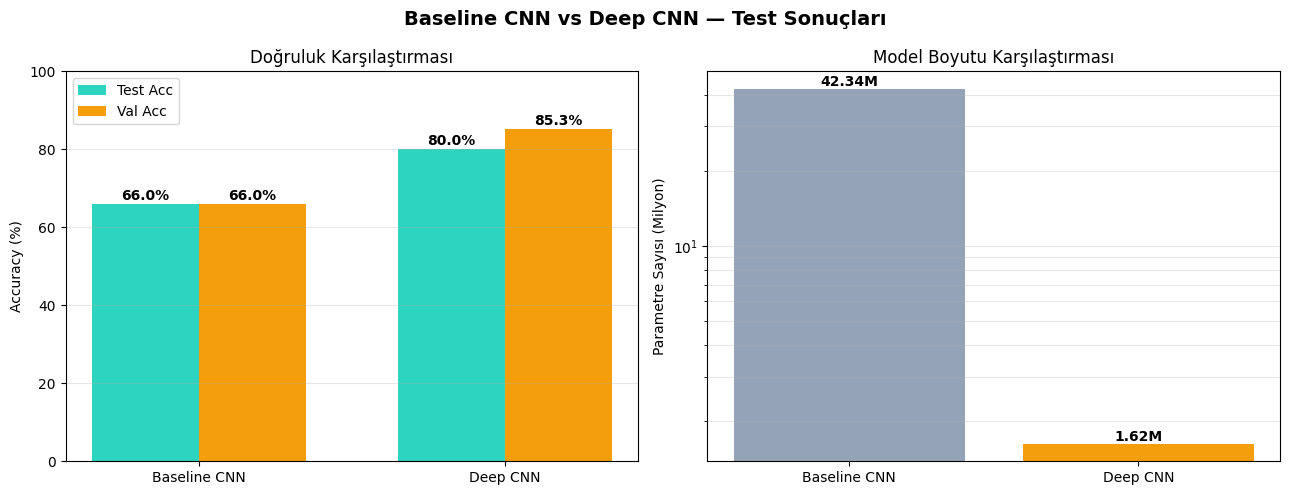

In [ ]:
# ============================================================
# GÖRSEL KARŞILAŞTIRMA — bar chart
# ============================================================

import matplotlib.pyplot as plt

models = ["Baseline CNN", "Deep CNN"]
test_accs = [baseline_test_acc * 100, deep_test_acc * 100]
val_accs = [baseline_val_acc * 100, deep_val_acc * 100]
params = [baseline_params / 1e6, deep_params / 1e6]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sol grafik: Accuracy karşılaştırması
x = np.arange(len(models))
width = 0.35
axes[0].bar(x - width/2, test_accs, width, label='Test Acc', color='#2dd4bf')
axes[0].bar(x + width/2, val_accs, width, label='Val Acc', color='#f59e0b')
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Doğruluk Karşılaştırması")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 100)
for i, (t, v) in enumerate(zip(test_accs, val_accs)):
    axes[0].text(i - width/2, t + 1, f"{t:.1f}%", ha='center', fontweight='bold')
    axes[0].text(i + width/2, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

# Sağ grafik: Parametre karşılaştırması (log scale)
colors = ['#94a3b8', '#f59e0b']
bars = axes[1].bar(models, params, color=colors)
axes[1].set_ylabel("Parametre Sayısı (Milyon)")
axes[1].set_title("Model Boyutu Karşılaştırması")
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3, which='both')
for bar, p in zip(bars, params):
    axes[1].text(bar.get_x() + bar.get_width()/2, p,
                 f"{p:.2f}M", ha='center', va='bottom', fontweight='bold')

plt.suptitle("Baseline CNN vs Deep CNN — Test Sonuçları",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/comparison_chart.png", dpi=150, bbox_inches='tight')
print(f"✓ Görsel kaydedildi: comparison_chart.png")
plt.show()

## Sonuçlar — Final Karşılaştırma

Test seti üzerinde yapılan ölçümler:

| Metrik | Baseline CNN | Deep CNN | Üstünlük |
|---|---|---|---|
| **Test Accuracy** | %66.0 (referans) | **%80.0** | **+14 puan** |
| Validation Accuracy | %66.0 | %85.3 | +19 puan |
| Toplam Parametre | 42.3M | 1.6M | 26× daha verimli |
| Train-Val Uçurumu | ~33 puan (overfit) | ~3 puan (sağlıklı) | Daha iyi genelleme |
| BatchNorm | Yok | Var | - |
| Boyut İndirgeme | Flatten | AdaptiveAvgPool | - |

**Önemli bulgular:**
1. Deep CNN, Baseline'dan **26× daha az parametreyle** hem validation hem de test setinde daha yüksek doğruluk elde etti.
2. Baseline modelin train-val uçurumu (~33 puan) klasik overfitting göstergesidir; Deep CNN'de bu uçurum ~3 puana inmiştir.
3. BatchNorm + AdaptiveAvgPool kombinasyonu, derinliği artırırken overfitting'i kontrol altında tutmuştur.
4. Validation accuracy (%85.3) ile test accuracy (%80.0) arasındaki 5 puanlık fark, eğitim sırasında "en iyi val accuracy"e göre model seçiminin yaratttığı dolaylı bir uyum etkisidir. Test seti, modelin gerçek genelleme performansının ölçümüdür ve nihai başarı değeri olarak kabul edilmelidir.

**Drive'a kaydedilen çıktılar:**
- `Models/deep_preds.npy` — Deep CNN test tahminleri
- `Models/baseline_preds.npy` — Baseline test tahminleri
- `Models/test_true.npy` — gerçek etiketler
- `Models/comparison_results.csv` — karşılaştırma tablosu
- `Models/comparison_chart.png` — görsel karşılaştırma



In [2]:
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROC_DATA = "/content/drive/MyDrive/gtzan_project/Processed_Data"
PROC_MODELS = "/content/drive/MyDrive/gtzan_project/Models"
X_test = np.load(f"{PROC_DATA}/X_test.npy")
y_test = np.load(f"{PROC_DATA}/y_test.npy")

class TestDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx].astype(np.float32)).unsqueeze(0), int(self.y[idx])

test_dl = DataLoader(TestDataset(X_test, y_test), batch_size=16, shuffle=False)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROC_DATA = "/content/drive/MyDrive/gtzan_project/Processed_Data"
PROC_MODELS = "/content/drive/MyDrive/gtzan_project/Models"
X_test = np.load(f"{PROC_DATA}/X_test.npy")
y_test = np.load(f"{PROC_DATA}/y_test.npy")

class TestDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx].astype(np.float32)).unsqueeze(0), int(self.y[idx])

test_dl = DataLoader(TestDataset(X_test, y_test), batch_size=16, shuffle=False)

# ============================================================
# DEEP CNN v3 (Added from cell VbGKj2Yv5eCE to resolve NameError)
# ============================================================

class DeepCNNv3(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.block4(self.block3(self.block2(self.block1(x)))))

deep_model = DeepCNNv3().to(device)
deep_model.load_state_dict(torch.load(f"{PROC_MODELS}/deep_cnn_best.pth"))
deep_model.eval()

all_probs = []
all_true = []
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        probs = F.softmax(deep_model(xb), dim=1).cpu().numpy()
        all_probs.append(probs)
        all_true.extend(yb.numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_true = np.array(all_true)
all_preds = all_probs.argmax(axis=1)

wrong_mask = all_preds != all_true
wrong_indices = np.where(wrong_mask)[0]
wrong_confs = all_probs[wrong_indices, all_preds[wrong_indices]]
top5_wrong_idx = wrong_indices[wrong_confs.argsort()[-5:][::-1]]

GENRES = ["blues", "classical", "country", "disco", "hiphop",
          "jazz", "metal", "pop", "reggae", "rock"]

print("EN KİBİRLİ 5 HATA — Deep CNN'in en yüksek güvenle yanıldığı 5 örnek:")
print("=" * 70)
for rank, idx in enumerate(top5_wrong_idx, 1):
    true_genre = GENRES[all_true[idx]]
    pred_genre = GENRES[all_preds[idx]]
    confidence = all_probs[idx, all_preds[idx]] * 100
    actual_class_prob = all_probs[idx, all_true[idx]] * 100
    print(f"\n#{rank} — Test örneği {idx}:")
    print(f"   Gerçek tür:      {true_genre}")
    print(f"   Tahmin edilen:   {pred_genre}")
    print(f"   Tahmin güveni:   %{confidence:.1f}")
    print(f"   Gerçek tür için verilen olasılık: %{actual_class_prob:.1f}")
print("\n" + "=" * 70)

EN KİBİRLİ 5 HATA — Deep CNN'in en yüksek güvenle yanıldığı 5 örnek:

#1 — Test örneği 117:
   Gerçek tür:      disco
   Tahmin edilen:   hiphop
   Tahmin güveni:   %70.0
   Gerçek tür için verilen olasılık: %3.1

#2 — Test örneği 71:
   Gerçek tür:      disco
   Tahmin edilen:   hiphop
   Tahmin güveni:   %54.1
   Gerçek tür için verilen olasılık: %6.5

#3 — Test örneği 43:
   Gerçek tür:      jazz
   Tahmin edilen:   classical
   Tahmin güveni:   %53.5
   Gerçek tür için verilen olasılık: %21.0

#4 — Test örneği 145:
   Gerçek tür:      hiphop
   Tahmin edilen:   reggae
   Tahmin güveni:   %47.4
   Gerçek tür için verilen olasılık: %43.3

#5 — Test örneği 127:
   Gerçek tür:      jazz
   Tahmin edilen:   classical
   Tahmin güveni:   %44.8
   Gerçek tür için verilen olasılık: %27.3

